# 01 · A dataset contract, a short fine-tune, and an honest test

Adapt ImageNet-pretrained ResNet18 to ten EuroSAT classes. A shared dataset adapter also serves the classical experiments in notebook 05. CPU works; CUDA is recommended. This is a small spatial transfer demonstration, not a benchmark of the complete dataset.

[Notebook index](README.md) · [Companion article](../docs/articles/reusable-geoai-framework.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data, workspace

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

## Inspect the data before choosing a model

The multispectral archive contains 13-band, 64 × 64 chips. We use original EuroSAT labels
and TorchGeo's longitude-based train/validation/test lists, sample each class with seed 42,
and exclude held-out footprints within 2 km of an earlier partition. The sampling manifest
preserves filenames, original georeferencing, archive identity, and individual chip hashes.
The effective distance is a design choice; it does not prove independence at every scale.

In [2]:
from geoai_portfolio.experiments import EuroSAT, group_bootstrap, report

data = ensure_data("eurosat")
out = workspace("01-framework")
dataset = EuroSAT.load(data)
display(pd.crosstab(dataset.samples["class"], dataset.samples.split))
print("Image tensor:", dataset.images.shape, dataset.images.dtype)

split,test,train,val
class,,,
AnnualCrop,50,200,50
Forest,50,200,50
HerbaceousVegetation,50,200,50
Highway,50,200,50
Industrial,50,200,50
Pasture,50,200,50
PermanentCrop,50,200,50
Residential,50,200,50
River,50,200,50


Image tensor: (2999, 13, 64, 64) uint16


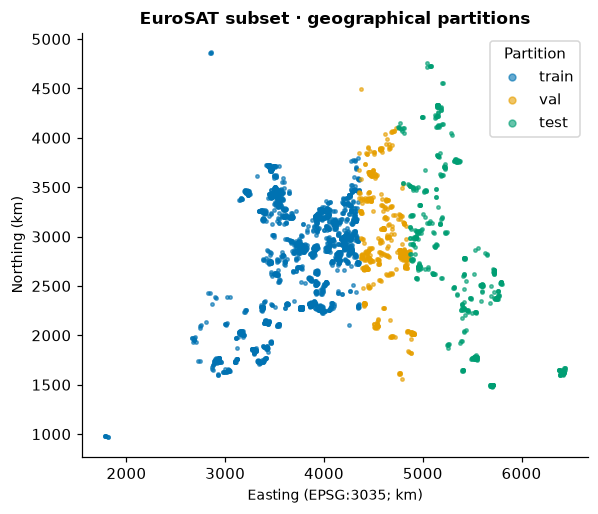

In [3]:
import geopandas as gpd

footprints = gpd.read_file(data / "footprints.gpkg")
fig, ax = plt.subplots(figsize=(9, 5))
for split, color in [("train", "#0072B2"), ("val", "#E69F00"), ("test", "#009E73")]:
    centers = footprints.loc[footprints.split.eq(split)].geometry.centroid
    ax.scatter(centers.x / 1000, centers.y / 1000, s=5, alpha=0.6, color=color, label=split)
ax.set(
    title="EuroSAT subset · geographical partitions",
    xlabel="Easting (EPSG:3035; km)",
    ylabel="Northing (km)",
    aspect="equal",
)
ax.legend(title="Partition", markerscale=2)
plt.show()

## Keep the experiment interface explicit

RGB band order is B04, B03, B02. Scaling by 10,000 retains EuroSAT's original DN convention;
this is not the C1 L2A calibration used in the Sentinel notebooks. Mean and standard deviation
are fitted on training chips only. A bilinear resize to 128 × 128 is a model input transform,
not an increase in geographical resolution. Pretrained weights supply the backbone; the
final layer starts with ten new outputs. Only layer4 and the classifier are updated.

In [4]:
import torch

from geoai_portfolio.neural import (
    device_name,
    fine_tune,
    infer,
    initialize_model,
    make_loaders,
    seed_everything,
)

seed_everything(42)
device = device_name(os.environ.get("GEOAI_DEVICE", "auto"))
loaders, preprocessing = make_loaders(dataset, batch_size=32)
model = initialize_model()
display(
    pd.DataFrame(
        {
            "band": preprocessing["bands"],
            "training_mean": preprocessing["mean"],
            "training_std": preprocessing["std"],
        }
    )
)
print(
    {
        "device": device,
        "torch": torch.__version__,
        "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "epochs": 3,
        "selection": "best validation macro-F1",
    }
)

<checkout>\src\geoai_portfolio\neural.py:47: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  labels = torch.as_tensor(dataset.samples.label.to_numpy(), dtype=torch.long)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to <user-home>/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


,band,training_mean,training_std
0,B04,0.0974,0.0609
1,B03,0.1064,0.0395
2,B02,0.1134,0.0341


{'device': 'cuda', 'torch': '2.14.0+cu130', 'trainable_parameters': 8398858, 'epochs': 3, 'selection': 'best validation macro-F1'}


## Train briefly and select using validation

Three epochs, AdamW (learning rate 0.0003, weight decay 0.001), batch size 32, seed 42.
Frozen batch-normalization statistics avoid adapting the pretrained backbone statistics
to tiny batches. There is no hyperparameter search on the test set. Timing describes this
execution and hardware only; deterministic settings do not promise identical floats
across different GPUs or dependency versions.

,epoch,train_loss,validation_macro_f1,seconds
0,1,0.5556,0.8837,1.2552
1,2,0.1594,0.8440,0.7206
2,3,0.0777,0.8778,0.7301


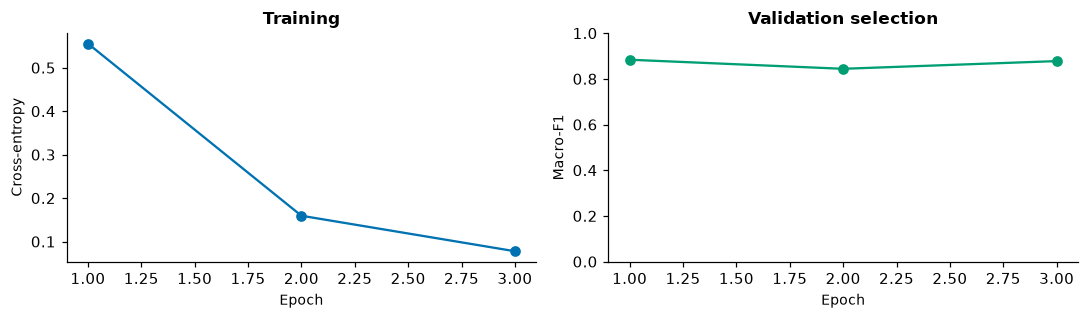

In [5]:
history = fine_tune(model, loaders, device=device, epochs=3)
display(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history.epoch, history.train_loss, "o-", color="#0072B2")
axes[0].set(title="Training", xlabel="Epoch", ylabel="Cross-entropy")
axes[1].plot(history.epoch, history.validation_macro_f1, "o-", color="#009E73")
axes[1].set(title="Validation selection", xlabel="Epoch", ylabel="Macro-F1", ylim=(0, 1))
plt.tight_layout()
plt.show()

## Evaluate once on the held-out geography

Macro-F1 weights the ten classes equally; support makes the sample size visible.
Bootstrap intervals resample 100 km spatial groups, not individual correlated chips.
These intervals describe this subset and grouping. They omit label uncertainty and
cannot establish accuracy in Portugal or any private operational project.

,precision,recall,f1-score,support
AnnualCrop,0.8500,0.6800,0.7556,50.0000
Forest,1.0000,0.8000,0.8889,50.0000
HerbaceousVegetation,0.5921,0.9000,0.7143,50.0000
Highway,0.8889,0.8000,0.8421,50.0000
Industrial,0.8070,0.9200,0.8598,50.0000
Pasture,0.8788,0.5800,0.6988,50.0000
PermanentCrop,0.7273,0.8000,0.7619,50.0000
Residential,0.9556,0.8600,0.9053,50.0000
River,0.8462,0.8800,0.8627,50.0000
SeaLake,0.8750,1.0000,0.9333,49.0000


,2.5%,median,97.5%
accuracy,0.7777,0.8225,0.8601
macro_f1,0.7644,0.8170,0.8488


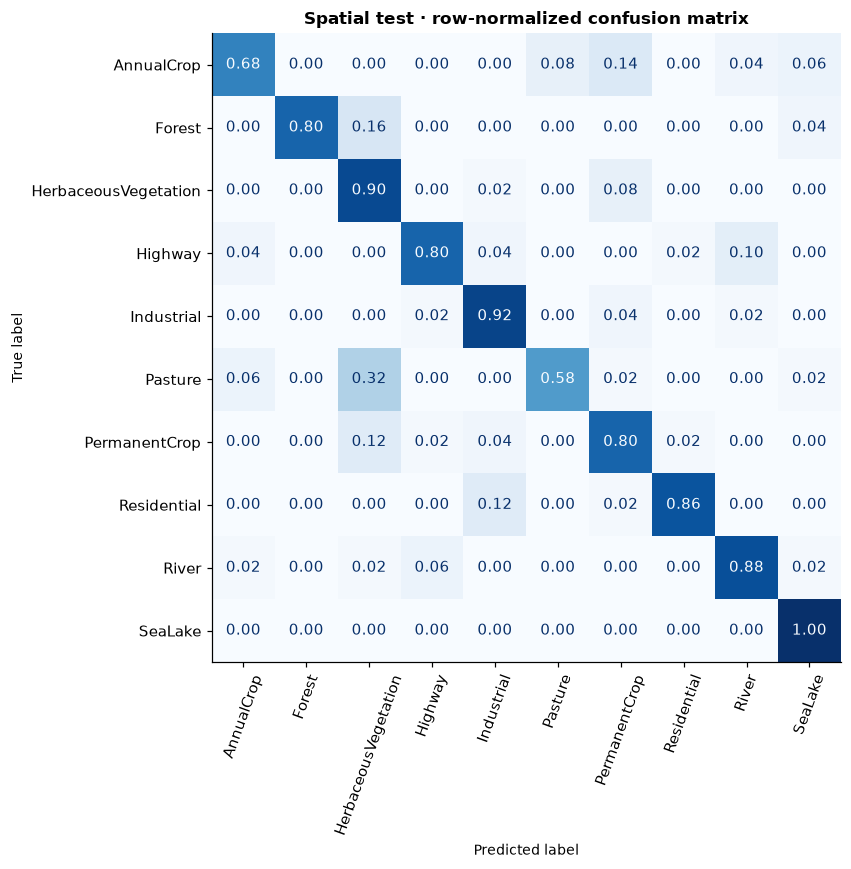

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

probability, truth = infer(model, loaders["test"], device)
predicted = probability.argmax(1)
display(report(dataset, predicted))
groups = dataset.samples.loc[dataset.mask("test"), "spatial_group"]
display(group_bootstrap(truth, predicted, groups))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    truth,
    predicted,
    labels=range(10),
    display_labels=dataset.classes,
    normalize="true",
    ax=ax,
    cmap="Blues",
    xticks_rotation=70,
    values_format=".2f",
    colorbar=False,
)
ax.set_title("Spatial test · row-normalized confusion matrix")
plt.tight_layout()
plt.show()

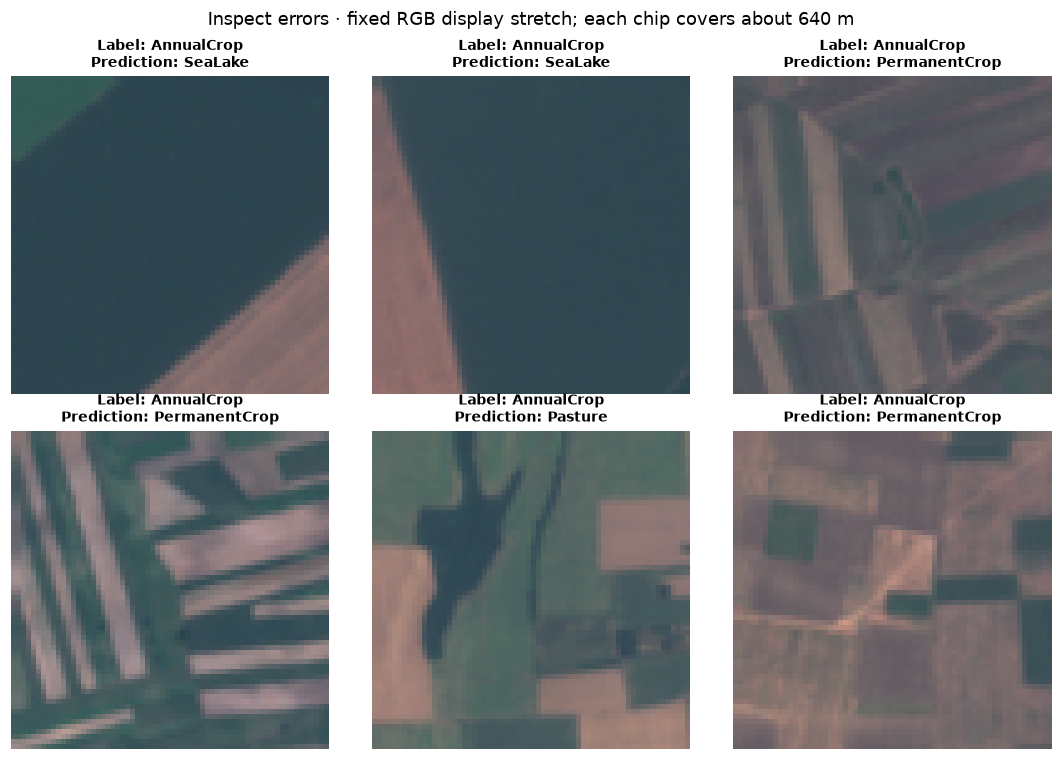

Saved local state dictionary and experiment metadata.


In [7]:
from geoai_portfolio.io import sha256, write_json

test_images = dataset.images[dataset.mask("test")]
errors = np.flatnonzero(predicted != truth)
chosen = errors[:6] if len(errors) else np.arange(6)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, index in zip(axes.flat, chosen):
    rgb = np.clip(test_images[index, [3, 2, 1]].transpose(1, 2, 0) / 3000, 0, 1)
    ax.imshow(rgb)
    ax.set_title(
        f"Label: {dataset.classes[truth[index]]}\nPrediction: {dataset.classes[predicted[index]]}",
        fontsize=9,
    )
    ax.axis("off")
fig.suptitle("Inspect errors · fixed RGB display stretch; each chip covers about 640 m")
plt.tight_layout()
plt.show()
torch.save(model.cpu().state_dict(), out / "resnet18-eurosat-state.pt")

write_json(
    out / "experiment.json",
    {
        "preprocessing": preprocessing,
        "seed": 42,
        "weights": "ResNet18_Weights.IMAGENET1K_V1",
        "selected_epoch": int(history.loc[history.validation_macro_f1.idxmax(), "epoch"]),
        "data_sha256": sha256(data / "samples.csv"),
        "device": device,
    },
)
print("Saved local state dictionary and experiment metadata.")

## Interpretation and next experiment

Inspect which visually similar classes are confused before adding model complexity.
The controlled comparison in [notebook 05](05-multispectral-experiments.ipynb) asks a
different question: does a fixed classical model benefit from additional bands?
ResNet's spatial image features and the forest's summary features are different
representations, so their scores are not an isolated comparison of architectures.

Sources: [EuroSAT authors](https://github.com/phelber/EuroSAT),
[TorchGeo spatial splits](https://torchgeo.readthedocs.io/en/latest/_modules/torchgeo/datasets/eurosat.html),
[torchvision ResNet18](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html).